In [39]:
!pip install pandas numpy scikit-learn nltk catboost matplotlib seaborn

In [58]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from catboost import CatBoostClassifier
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report
from sklearn.svm import SVC

In [41]:
# Определение положения тела при пользовании смартфоном

# Загрузка датасета для обучения
data_train = pd.read_csv('/content/train.csv')

data_train.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,1,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,1,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,1,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,1,STANDING


EDA

In [42]:
# Размер датасета
data_train.shape

(7352, 563)

In [43]:
# Наличие незаполненных ячеек
data_train.isnull().sum()

,0
tBodyAcc-mean()-X,0
tBodyAcc-mean()-Y,0
tBodyAcc-mean()-Z,0
tBodyAcc-std()-X,0
tBodyAcc-std()-Y,0
...,...
"angle(X,gravityMean)",0
"angle(Y,gravityMean)",0
"angle(Z,gravityMean)",0
subject,0


In [44]:
# Список типов активности для классификации
data_train['Activity'].unique()

array(['STANDING', 'SITTING', 'LAYING', 'WALKING', 'WALKING_DOWNSTAIRS',
       'WALKING_UPSTAIRS'], dtype=object)

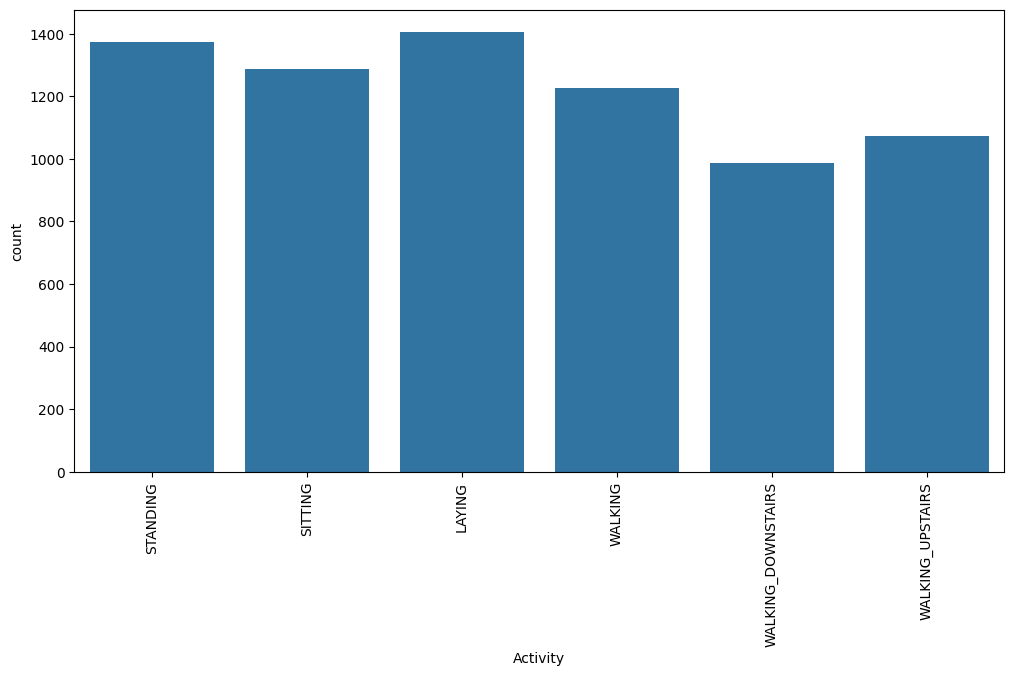

In [45]:
plt.figure(figsize=(12,6))
axis = sns.countplot(x='Activity',data=data_train)
plt.xticks(x=data_train['Activity'],rotation='vertical')
plt.show()

Подготовка данных

In [46]:
# Разделение признаков
# дропаем признак subject, описывающий тестировщиков, собиравших данные
X = data_train.drop(['Activity','subject'],axis=1)
y = data_train['Activity']

X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7352 entries, 0 to 7351
Columns: 561 entries, tBodyAcc-mean()-X to angle(Z,gravityMean)
dtypes: float64(561)
memory usage: 31.5 MB


In [47]:
num_cols = X._get_numeric_data().columns
print('Число числовых параметров:',num_cols.size)

Число числовых параметров: 561


In [48]:
# приведение текстовых полей к числовым значениям
encoder_train = preprocessing.LabelEncoder()
encoder_train.fit(y)
y = encoder_train.transform(y)
y

array([2, 2, 2, ..., 5, 5, 5])

In [49]:
encoder_train.classes_

array(['LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_DOWNSTAIRS',
       'WALKING_UPSTAIRS'], dtype=object)

In [50]:
# нормализация данных
scaler_train = preprocessing.StandardScaler()
X = scaler_train.fit_transform(X)

Обучение модели

In [54]:
# Выборки для обучающего и тестового датасетов
'''
# Разделение обучающего датасета для обучения
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.30,random_state=100)
'''

# Использование отдельного тестового датасета
X_train = X
y_train = y

# Подготовка тестового датасета
data_test = pd.read_csv('/content/test.csv')
X_test = data_test.drop(['Activity','subject'],axis=1)
y_test = data_test['Activity']

scaler_test=preprocessing.StandardScaler()
X_test = scaler_test.fit_transform(X_test)

encoder_test = preprocessing.LabelEncoder()
encoder_test.fit(y_test)
y_test = encoder_test.transform(y_test)

# проверка соответствия категорий в обучающем и тестовом датасетах
print(encoder_train.classes_)
print(encoder_test.classes_)

['LAYING' 'SITTING' 'STANDING' 'WALKING' 'WALKING_DOWNSTAIRS'
 'WALKING_UPSTAIRS']
['LAYING' 'SITTING' 'STANDING' 'WALKING' 'WALKING_DOWNSTAIRS'
 'WALKING_UPSTAIRS']


In [55]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((7352, 561), (2947, 561), (7352,), (2947,))

In [56]:
# Инициализация моделей
models = {
    'SVC': SVC(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'CatBoost': CatBoostClassifier(),
    'AdaBoost': AdaBoostClassifier(),
    'Extra Trees': ExtraTreesClassifier(),
    'QDA': QuadraticDiscriminantAnalysis()
}

In [62]:
results = []

for name, model in models.items():
    print(f'Обучение {name}...')
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

# Подсчет метрик:
# accuracy - общая точность
# f1 - гармоническое среднее между precision и recall
# precision - доля верных предсказаний (учет ложноположительных обнаружений)
# recall - доля верно определенных положений (учет ложноотрицательных обнаружений)
# classification_report позволяет получить более детальную информацию
    accuracy = accuracy_score(y_test, y_pred)
    print(f'Точность (Acc): {accuracy}')
    f1 = f1_score(y_test, y_pred, average='macro')
    print(f'F1: {f1}')
    precision = precision_score(y_test, y_pred, average='macro')
    print(f'Точность (Pre): {precision}')
    recall = recall_score(y_test, y_pred, average='macro')
    print(f'Полнота: {recall}\n')
    print(classification_report(y_test, y_pred))

    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'F1': f1,
        'Precision': precision,
        'Recall': recall
    })

print('Результаты сравнения моделей:')
print(pd.DataFrame(results).sort_values('F1'))

Обучение SVC...
Точность (Acc): 0.9562266711910418
F1: 0.9555189281010273
Точность (Pre): 0.9558651736119291
Полнота: 0.9555011907780729

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       537
           1       0.93      0.92      0.93       491
           2       0.94      0.94      0.94       532
           3       0.98      0.95      0.97       496
           4       0.95      0.93      0.94       420
           5       0.94      0.99      0.96       471

    accuracy                           0.96      2947
   macro avg       0.96      0.96      0.96      2947
weighted avg       0.96      0.96      0.96      2947

Обучение Gradient Boosting...
Точность (Acc): 0.9321343739395996
F1: 0.931990882978656
Точность (Pre): 0.9342826505727723
Полнота: 0.9331180753825388

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       537
           1       0.82      0.95      0.88       491
     

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m

Точность (Acc): 0.9440108585001696
F1: 0.9423048001038746
Точность (Pre): 0.9425812387340198
Полнота: 0.9426218349481408

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       537
           1       0.91      0.95      0.93       491
           2       0.95      0.91      0.93       532
           3       0.96      0.93      0.95       496
           4       0.91      0.90      0.90       420
           5       0.92      0.96      0.94       471

    accuracy                           0.94      2947
   macro avg       0.94      0.94      0.94      2947
weighted avg       0.94      0.94      0.94      2947

Обучение QDA...


/usr/local/lib/python3.11/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 2 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 3 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/p

Точность (Acc): 0.17441465897522904
F1: 0.08923819460730847
Точность (Pre): 0.07986772112389824
Полнота: 0.16242567545493156

              precision    recall  f1-score   support

           0       0.01      0.01      0.01       537
           1       0.00      0.00      0.00       491
           2       0.23      0.84      0.36       532
           3       0.24      0.12      0.16       496
           4       0.00      0.00      0.00       420
           5       0.00      0.00      0.00       471

    accuracy                           0.17      2947
   macro avg       0.08      0.16      0.09      2947
weighted avg       0.08      0.17      0.09      2947

Результаты сравнения моделей:
               Model  Accuracy        F1  Precision    Recall
5                QDA  0.174415  0.089238   0.079868  0.162426
3           AdaBoost  0.349169  0.202496   0.146983  0.333699
1  Gradient Boosting  0.932134  0.931991   0.934283  0.933118
2           CatBoost  0.938242  0.938016   0.938329  

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m